In [1]:
# ============================================================
# Credit Card Fraud Detection
# Step 4: Model Training & Evaluation
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


In [2]:
df = pd.read_csv(r'C:\Users\harsh\Downloads\fraude detection\final_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (946, 16)


,V14,V10,V17,V4,V11,V3,V12,V16,V7,V2,V19,V21,NormalizedAmount,V27,V9,Class
0,-4.289254,-2.772272,-2.830056,3.997906,3.202033,-1.609851,-2.899907,-1.140747,-2.537387,1.951992,0.416956,0.517232,-0.305938,0.261145,-2.770089,1
1,-1.692029,-0.838587,0.599717,2.288644,-0.414575,1.088463,-0.503141,0.666780,0.325574,-3.157307,0.283345,0.661696,7.050480,-0.252773,-0.270953,1
2,-1.470102,-1.525412,-4.781831,2.330243,2.032912,-0.359745,-6.560124,-2.282194,0.562320,1.759247,-1.334441,-0.294166,3.030594,0.039566,-0.238253,1
3,-6.771097,-4.801637,-12.598419,2.679787,4.895844,-2.592844,-10.912819,-7.358083,-3.496197,1.358367,0.308334,0.573574,0.514532,-0.827136,-0.247768,1
4,-6.079337,-2.447469,6.739384,4.732795,2.101344,-4.304597,-4.609628,2.581851,1.713445,3.019740,-2.721853,-0.379068,-0.292032,-0.010016,-1.282858,1


In [3]:
X = df.drop('Class', axis=1)
Y = df['Class']

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("\nClass Distribution:\n", Y.value_counts())

X shape: (946, 15)
Y shape: (946,)

Class Distribution:
 Class
1    473
0    473
Name: count, dtype: int64


In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (756, 15)
Test size: (190, 15)


In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, Y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(Y_test, pred)
    roc = roc_auc_score(Y_test, model.predict_proba(X_test)[:,1])
    results[name] = {'Accuracy': acc, 'ROC-AUC': roc}
    print(f"\n=== {name} ===")
    print("Accuracy:", round(acc*100, 2), "%")
    print("ROC-AUC:", round(roc, 4))
    print(classification_report(Y_test, pred))


=== Logistic Regression ===
Accuracy: 94.21 %
ROC-AUC: 0.977
              precision    recall  f1-score   support

           0       0.90      0.99      0.94        95
           1       0.99      0.89      0.94        95

    accuracy                           0.94       190
   macro avg       0.95      0.94      0.94       190
weighted avg       0.95      0.94      0.94       190


=== Random Forest ===
Accuracy: 94.21 %
ROC-AUC: 0.9775
              precision    recall  f1-score   support

           0       0.90      0.99      0.94        95
           1       0.99      0.89      0.94        95

    accuracy                           0.94       190
   macro avg       0.95      0.94      0.94       190
weighted avg       0.95      0.94      0.94       190


=== XGBoost ===
Accuracy: 94.74 %
ROC-AUC: 0.9852
              precision    recall  f1-score   support

           0       0.92      0.98      0.95        95
           1       0.98      0.92      0.95        95

    accuracy

                     Accuracy   ROC-AUC
Logistic Regression  0.942105  0.976953
Random Forest        0.942105  0.977452
XGBoost              0.947368  0.985152
SVM                  0.947368  0.978504


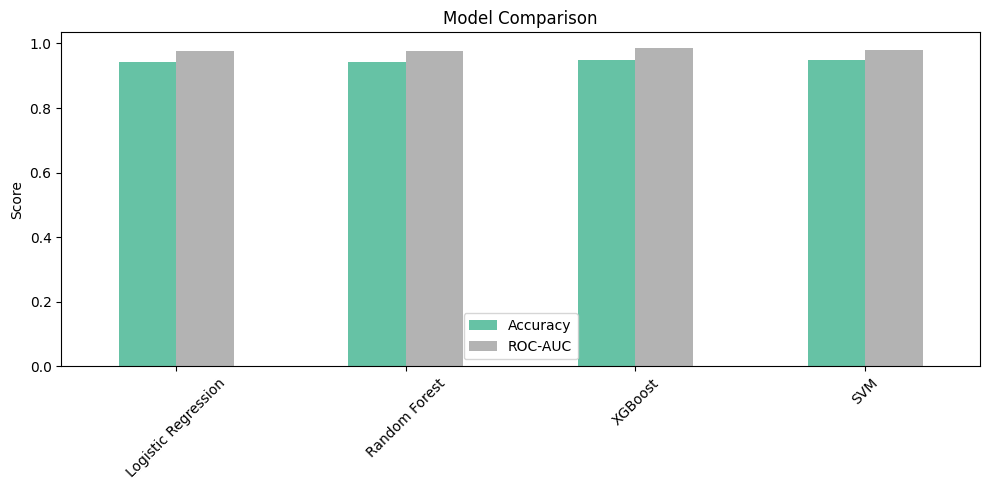

In [6]:
results_df = pd.DataFrame(results).T
print(results_df)

results_df.plot(kind='bar', figsize=(10,5), colormap='Set2')
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

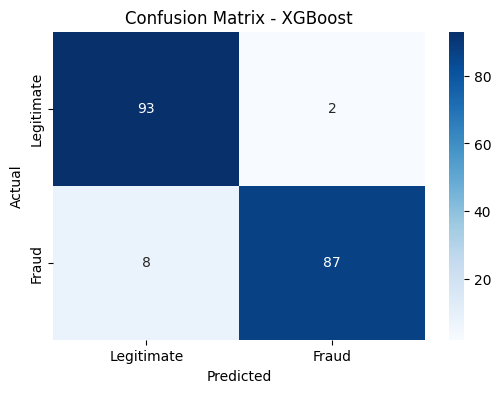

In [7]:
best_model = models['XGBoost']
Y_pred = best_model.predict(X_test)

cm = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate','Fraud'],
            yticklabels=['Legitimate','Fraud'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

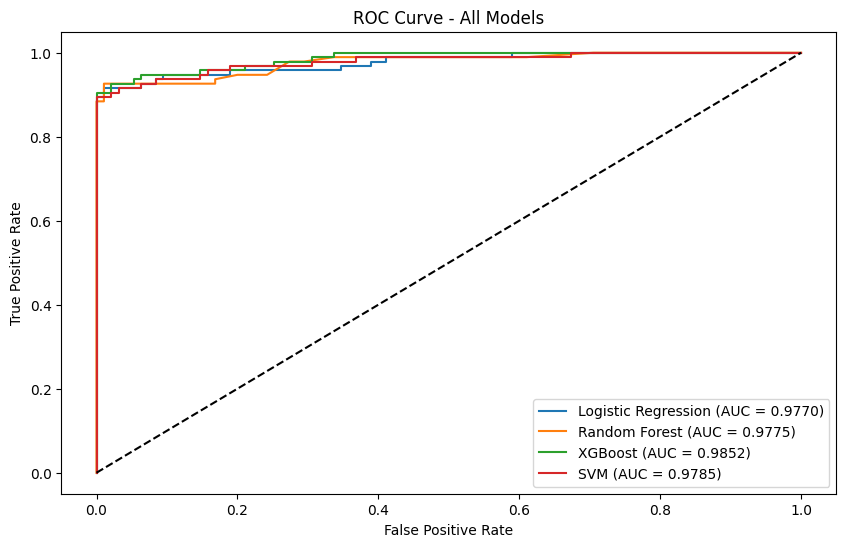

In [8]:
plt.figure(figsize=(10,6))

for name, model in models.items():
    fpr, tpr, _ = roc_curve(Y_test, model.predict_proba(X_test)[:,1])
    auc = roc_auc_score(Y_test, model.predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - All Models')
plt.legend()
plt.show()

In [9]:
print("=== Cross Validation (5-Fold) ===\n")

for name, model in models.items():
    scores = cross_val_score(model, X, Y, cv=5, scoring='accuracy')
    print(f"{name}: {round(scores.mean()*100, 2)}% (+/- {round(scores.std()*100, 2)}%)")

=== Cross Validation (5-Fold) ===

Logistic Regression: 93.76% (+/- 1.85%)
Random Forest: 93.34% (+/- 1.6%)
XGBoost: 92.91% (+/- 2.06%)
SVM: 93.23% (+/- 1.76%)


In [10]:
with open(r'C:\Users\harsh\Downloads\fraude detection\fraud_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Best Model (XGBoost) Saved Successfully! ✅")

Best Model (XGBoost) Saved Successfully! ✅


In [11]:
# Update best model to Logistic Regression
best_model = models['Logistic Regression']

import pickle
with open(r'C:\Users\harsh\Downloads\fraude detection\fraud_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Best Model (Logistic Regression) Saved! ✅")

Best Model (Logistic Regression) Saved! ✅
